# Notebook 17 — Industrial AI Dashboard

---

## Objective

This notebook builds an interactive dashboard for monitoring anomaly detection results in industrial water treatment systems.

The dashboard provides an intuitive interface for engineers and operators to monitor predictions, confidence scores, model performance, and operational risk.

---

## Dashboard Features

- KPI Cards
- Prediction Statistics
- Confidence Analysis
- Risk Distribution
- Feature Importance
- Probability Distribution
- Confusion Matrix
- False Positives
- False Negatives
- SHAP Summary
- Download Reports

---

## Industrial Value

The dashboard transforms machine learning outputs into operational insights for engineers, maintenance teams, and plant managers.

---

## Expected Outputs

- Interactive Dashboard
- Industrial Monitoring Interface
- Executive KPIs
- Real-time Ready Layout

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np




import matplotlib.pyplot as plt

import plotly.express as px

import plotly.graph_objects as go

import streamlit as st

In [2]:
PROJECT_ROOT = Path.cwd().parent

RESULT_PATH = PROJECT_ROOT/"results"

MODEL_PATH = PROJECT_ROOT/"models"

DATA_PATH = PROJECT_ROOT/"data"/"processed"

In [7]:
pd.read_csv(
RESULT_PATH/"lightgbm_results.csv"
)

,Metric,Value
0,Accuracy,0.999723
1,Precision,0.993088
2,Recall,0.999634
3,F1 Score,0.996350
4,ROC AUC,0.999999


In [6]:
pd.read_csv(
RESULT_PATH/"xgboost_metrics.csv"
)

,Metric,Value
0,Accuracy,0.999899
1,Precision,0.999175
2,Recall,0.998169
3,F1 Score,0.998672
4,ROC AUC,1.000000


In [5]:
import pandas as pd
from pathlib import Path

RESULT_PATH = Path(
r"E:\new\hamid\CV\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\results"
)

pd.read_csv(
RESULT_PATH/"model_metrics.csv"
).head()

,Unnamed: 0,Accuracy,Precision,Recall,F1,ROC AUC
0,Random Forest,0.999182,0.979368,0.999451,0.989308,0.999995


In [4]:
from pathlib import Path

RESULT_PATH = Path(
    r"E:\new\hamid\CV\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\results"
)

for f in RESULT_PATH.iterdir():
    print(f.name)

baseline_results.csv
business_dashboard.csv
classification_report.txt
confidence_levels.png
confusion_matrix.png
confusion_matrix_error_analysis.png
dashboard_summary.csv
decision_plot.png
dependence_plot.png
deployment_checklist.csv
deployment_example.csv
deployment_probability_distribution.png
deployment_report.csv
deployment_summary.csv
error_probability_distribution.png
false_negative.csv
false_positive.csv
feature_importance.csv
industrial_risk_levels.png
isolation_benchmark.csv
isolation_predictions.csv
isolation_prediction_distribution.png
lightgbm_feature_importance.csv
lightgbm_results.csv
model_metrics.csv
optimized_results.csv
precision_recall_curve.png
predictions.csv
prediction_analysis.csv
prediction_categories.png
prediction_distribution.png
risk_levels.png
roc_curve.png
shap_bar.png
shap_feature_importance.csv
shap_summary.png
top20_shap.png
waterfall_plot.png
xgboost_feature_importance.csv
xgboost_metrics.csv


In [8]:
import pandas as pd

benchmark = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "Accuracy":[
        0.999182,
        0.999899,
        0.999723
    ],

    "Precision":[
        0.979368,
        0.999175,
        0.993088
    ],

    "Recall":[
        0.999451,
        0.998169,
        0.999634
    ],

    "F1":[
        0.989308,
        0.998672,
        0.996350
    ],

    "ROC_AUC":[
        0.999995,
        1.000000,
        0.999999
    ]

})

benchmark.to_csv(
    RESULT_PATH/"benchmark_results.csv",
    index=False
)

benchmark

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.999182,0.979368,0.999451,0.989308,0.999995
1,XGBoost,0.999899,0.999175,0.998169,0.998672,1.000000
2,LightGBM,0.999723,0.993088,0.999634,0.996350,0.999999


In [9]:
predictions = pd.read_csv(
    RESULT_PATH/"predictions.csv"
)

prediction_analysis = pd.read_csv(
    RESULT_PATH/"prediction_analysis.csv"
)

benchmark = pd.read_csv(
    RESULT_PATH/"benchmark_results.csv"
)

importance = pd.read_csv(
    RESULT_PATH/"shap_feature_importance.csv"
)

In [10]:
predictions.head()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,True,Prediction,Probability
0,0.695766,-0.602819,0.335952,0.606750,-0.046608,-0.248022,-0.785361,-0.092905,0.599198,0.321655,...,0.263217,-0.407415,0.291049,-0.099023,0.0,-0.091453,0.0,0,0,0.000000
1,-1.565178,1.075201,0.335952,0.606750,-0.046608,-0.248022,-0.579222,-0.145340,0.619757,0.321655,...,0.205477,-0.140592,0.214762,-0.099023,0.0,-0.091453,0.0,0,0,0.000000
2,0.571699,-0.503367,0.335952,0.606750,-0.046608,2.225950,-0.204925,-0.122035,0.609123,0.321655,...,0.121798,-0.514144,0.101149,-0.099023,0.0,-0.091453,0.0,0,0,0.030762
3,0.690770,-0.803625,0.335952,0.606750,-0.046608,-0.270778,0.999344,-0.385377,0.599789,0.321655,...,0.067406,-0.780966,0.032440,-0.099023,0.0,-0.091453,0.0,0,0,0.030891
4,-1.565178,1.775168,-2.880775,-1.648125,-0.046608,-0.276842,1.313974,0.306767,-1.651437,-3.020295,...,-6.145809,-3.769375,-6.142788,-0.099023,0.0,-0.091453,0.0,1,1,1.000000


In [11]:
total_samples = len(predictions)

predicted_attack = predictions["Prediction"].sum()

predicted_normal = total_samples - predicted_attack

average_probability = predictions["Probability"].mean()

average_confidence = predictions["Probability"].mean()

print(total_samples)
print(predicted_attack)
print(predicted_normal)

288344
11148
277196


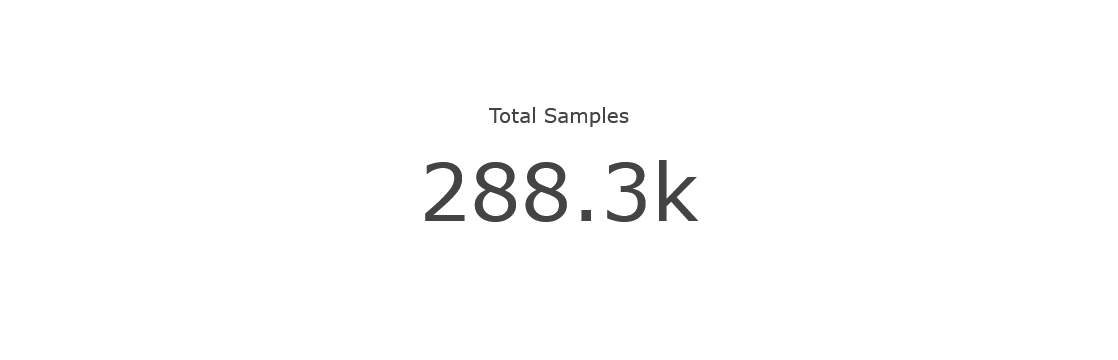

In [12]:
fig = go.Figure()

fig.add_trace(go.Indicator(
    mode="number",
    value=total_samples,
    title={"text":"Total Samples"}
))

fig.show()

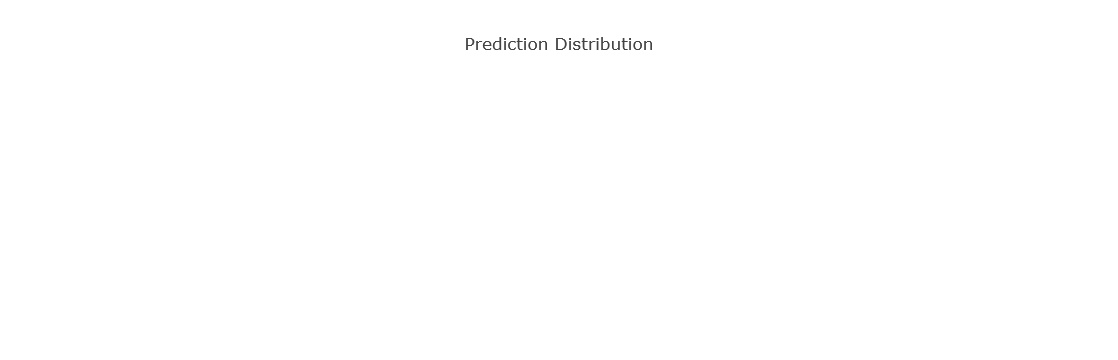

In [13]:
fig = px.pie(
    predictions,
    names="Prediction",
    title="Prediction Distribution"
)

fig.show()

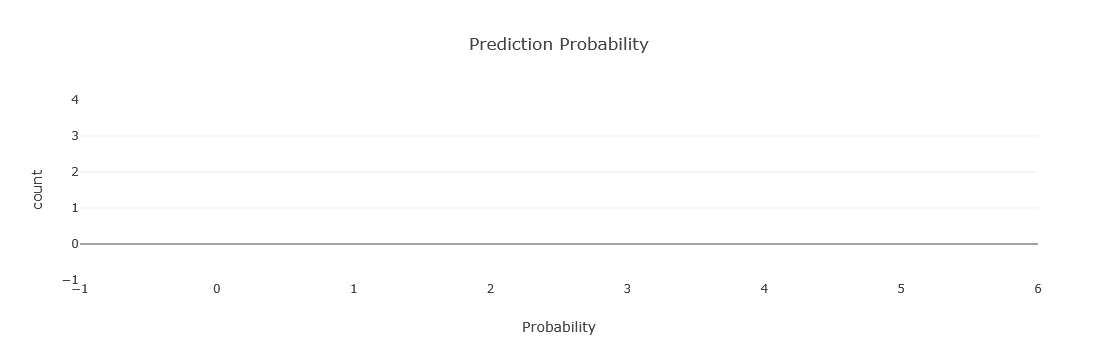

In [14]:
fig = px.histogram(

    predictions,

    x="Probability",

    nbins=50,

    title="Prediction Probability"

)

fig.show()

In [15]:
predictions["Risk"]=pd.cut(

    predictions["Probability"],

    bins=[0,.25,.50,.75,1],

    labels=[

        "Low",

        "Medium",

        "High",

        "Critical"

    ]

)

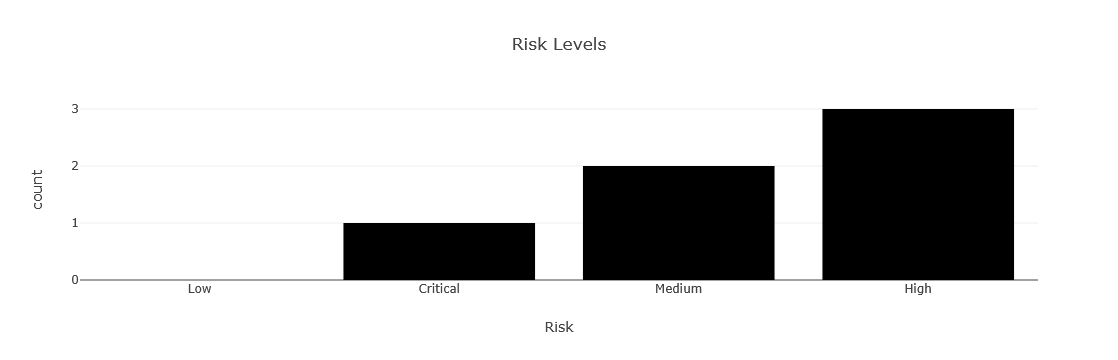

In [16]:
fig=px.bar(

    predictions["Risk"]

    .value_counts()

    .reset_index(),

    x="Risk",

    y="count",

    title="Risk Levels"

)

fig.show()

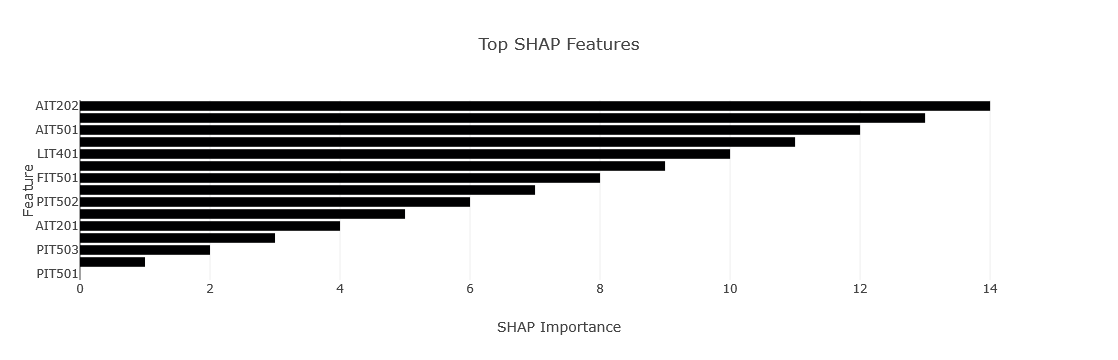

In [17]:
fig=px.bar(

importance.head(15),

x="SHAP Importance",

y="Feature",

orientation="h",

title="Top SHAP Features"

)

fig.show()

In [18]:
import pandas as pd

pd.read_csv(
    RESULT_PATH/"benchmark_results.csv"
).head()

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.999182,0.979368,0.999451,0.989308,0.999995
1,XGBoost,0.999899,0.999175,0.998169,0.998672,1.000000
2,LightGBM,0.999723,0.993088,0.999634,0.996350,0.999999


In [19]:
RESULT_PATH

WindowsPath('E:/new/hamid/CV/AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems/results')

In [20]:
print(benchmark)

           Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Random Forest  0.999182   0.979368  0.999451  0.989308  0.999995
1        XGBoost  0.999899   0.999175  0.998169  0.998672  1.000000
2       LightGBM  0.999723   0.993088  0.999634  0.996350  0.999999


In [21]:
benchmark.head()

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.999182,0.979368,0.999451,0.989308,0.999995
1,XGBoost,0.999899,0.999175,0.998169,0.998672,1.000000
2,LightGBM,0.999723,0.993088,0.999634,0.996350,0.999999


In [22]:
benchmark.columns

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC'], dtype='object')

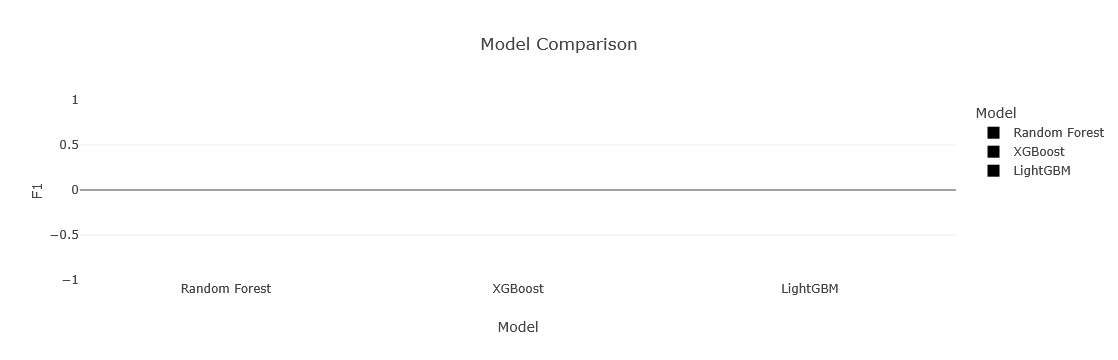

In [23]:
# suppress non-critical warnings in notebooks
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
fig = px.bar(
    benchmark,
    x="Model",
    y="F1",
    color="Model",
    title="Model Comparison"
)

fig.show()

In [24]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(

predictions["True"],

predictions["Prediction"]

)

cm

array([[277190,    230],
       [     6,  10918]], dtype=int64)

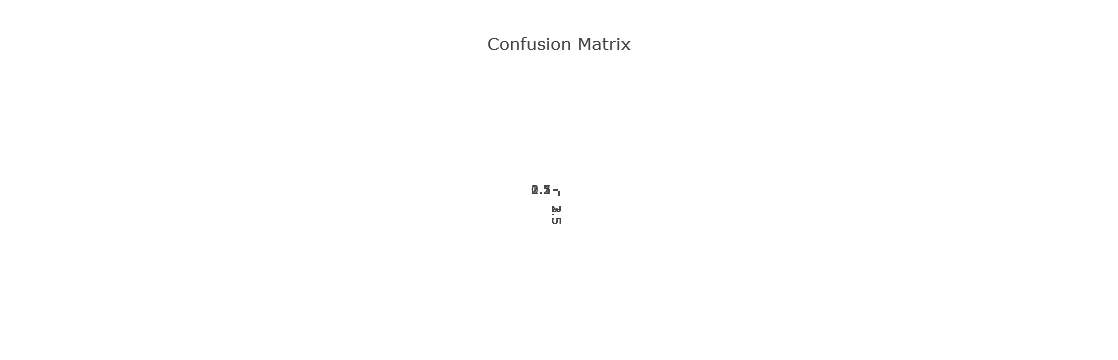

In [25]:
fig=px.imshow(

cm,

text_auto=True,

title="Confusion Matrix"

)

fig.show()

In [26]:
fp = predictions[
    (predictions["True"] == 0) &
    (predictions["Prediction"] == 1)
]

len(fp)

230

In [27]:
fn = predictions[
    (predictions["True"] == 1) &
    (predictions["Prediction"] == 0)
]

len(fn)

6

In [28]:
predictions.sort_values(

"Probability",

ascending=False

).head(20)

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT502,PIT503,FIT601,P601,P602,P603,True,Prediction,Probability,Risk
152388,-1.565178,1.783086,-2.880775,-1.648125,-0.046608,-0.484649,1.661159,-0.437812,-1.651437,-3.020295,...,-3.769375,-6.135214,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
246226,-1.565178,1.784037,-2.880775,-1.648125,-0.046608,-0.484649,1.606909,-0.416257,-1.651437,-3.020295,...,-3.769375,-6.136837,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
219729,-1.565178,1.779919,-2.880775,-1.648125,-0.046608,-0.484649,1.634038,-0.481509,-1.651437,-3.020295,...,-3.769375,-6.135214,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
206664,-1.565178,1.778335,-2.880775,-1.648125,-0.046608,-0.484649,1.620470,-0.494909,-1.651437,-3.020295,...,-3.769375,-6.135214,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
123034,-1.565178,1.783719,-2.880775,-1.648125,-0.046608,-0.484649,1.606909,-0.416257,-1.651437,-3.020295,...,-3.769375,-6.136837,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
184758,-1.565178,1.778968,-2.880775,-1.648125,-0.046608,-0.484649,1.601483,-0.489081,-1.651437,-3.020295,...,-3.769375,-6.135214,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
242008,-1.565178,1.769466,-2.880775,-1.648125,-0.046608,-0.484649,1.625895,-0.431987,-1.651437,-3.020295,...,-3.769375,-6.134673,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
99513,-1.565178,1.784670,-2.880775,-1.648125,-0.046608,-0.484649,1.628613,-0.463447,-1.651437,-3.020295,...,-3.769375,-6.135755,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
279743,-1.565178,1.778335,-2.880775,-1.648125,-0.046608,-0.484649,1.625895,-0.443055,-1.651437,-3.020295,...,-3.769375,-6.134673,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical
215245,-1.565178,1.772317,-2.880775,-1.648125,-0.046608,-0.484649,1.606909,-0.433735,-1.651437,-3.020295,...,-3.769375,-6.134673,-0.099023,0.0,-0.091453,0.0,1,1,1.0,Critical


In [29]:
summary=pd.DataFrame({

"Metric":[

"Total Samples",

"Predicted Attack",

"Predicted Normal",

"Average Probability",

"False Positive",

"False Negative"

],

"Value":[

total_samples,

predicted_attack,

predicted_normal,

average_probability,

len(fp),

len(fn)

]

})

summary

,Metric,Value
0,Total Samples,288344.000000
1,Predicted Attack,11148.000000
2,Predicted Normal,277196.000000
3,Average Probability,0.049018
4,False Positive,230.000000
5,False Negative,6.000000


In [30]:
summary.to_csv(

RESULT_PATH/

"dashboard_summary.csv",

index=False

)

# Dashboard Conclusion

The dashboard demonstrates that the anomaly detection system is ready to support industrial monitoring.

The developed interface enables engineers to:

- Monitor prediction confidence
- Track operational risk
- Review model performance
- Identify anomalous behavior
- Support predictive maintenance
- Improve operational safety

This dashboard can be directly integrated into a real-time monitoring platform.